# 1 - Introduction to Data Analysis

Import the libraries **pandas, numpy, sklearn, lightgbm, scipy, statsmodels, matplotlib, seaborn**.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

Load data from kaggle using **pandas**. You only need the table data, which is in **train.json**.

In [2]:
df_init = pd.read_json('data/train.json')
df_init.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


What is the size (the number of rows and columns) of your data?

In [3]:
df_init.shape

(49352, 15)

Print the list of columns. Which column is a target?

In [4]:
df_init.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

**price** is a target column

Make a quick analysis of the data: use the methods **info(), describe(), corr()**. Explain the results of the outputs. Are there any empty columns?

In [5]:
df_init.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


results of **info()**: 15 columns, each column has 49352 non-null values

In [6]:
df_init.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


results of **describe()**: mean price 3830, max price 4490000 - data contains outliers

In [7]:
df_init[['bathrooms', 'bedrooms', 'latitude', 'listing_id', 'longitude', 'price']].corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


results of **corr()**: correlation to price is small; big correlation between latitude and longitude (-0.966807)

In [8]:
df_init.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

there are no empty columns

We'll work with only 3 features: 'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'. Create a dataframe with only these columns.

In [9]:
df = df_init[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


# 2 - Statistical Data Analysis

## Target analysis

Plot a histogram to understand the distribution of the target. Is it all clear?

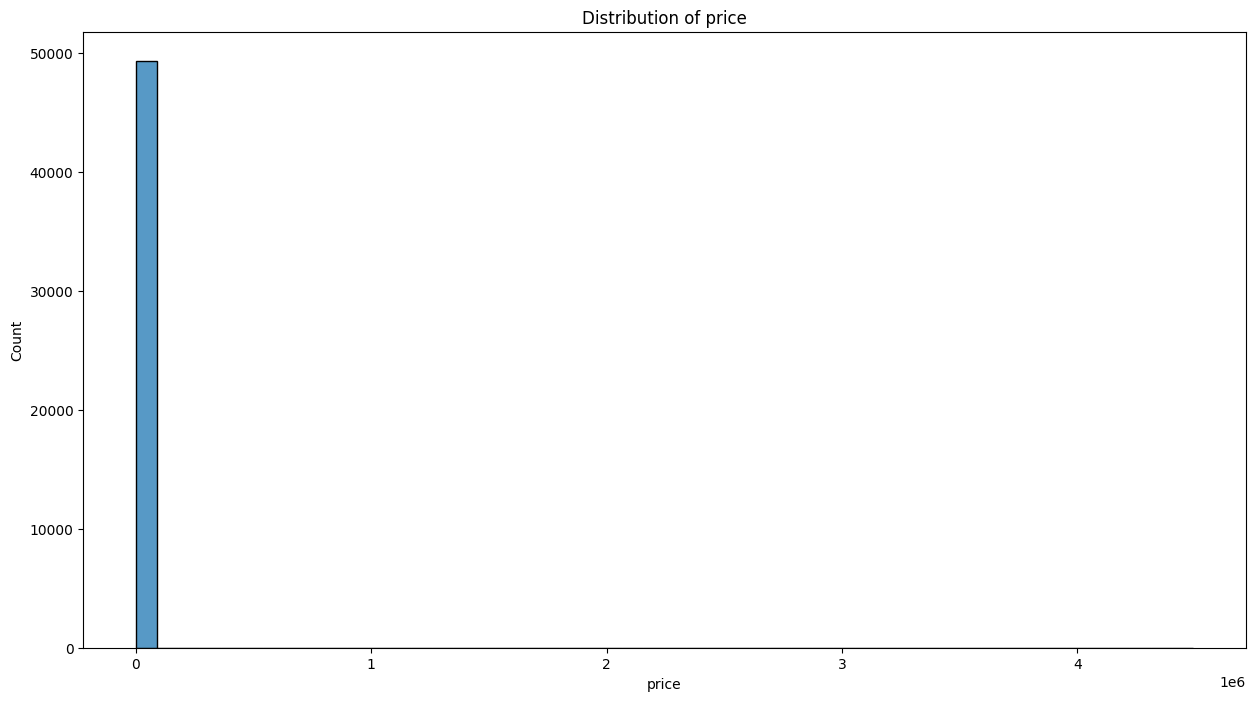

In [10]:
plt.figure(figsize=(15,8))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of price")
plt.show()

The next step is boxplot(). What can you say about the target? Are there any outliers?

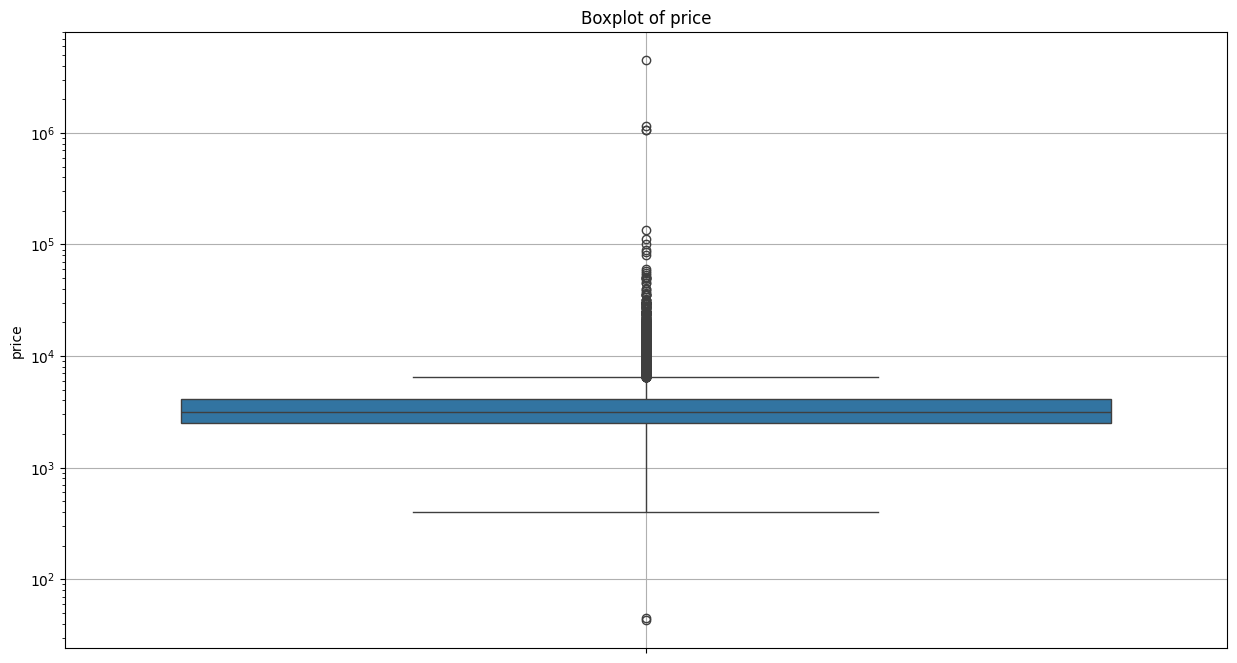

In [11]:
plt.figure(figsize=(15, 8))
sns.boxplot(df['price'])
plt.title('Boxplot of price')
plt.grid()
plt.yscale('log')
plt.show()

Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [12]:
df = df[(df['price'] >= df['price'].quantile(0.01)) & (df['price'] <= df['price'].quantile(0.99))]

Plot another histogram for price. Explain the result.

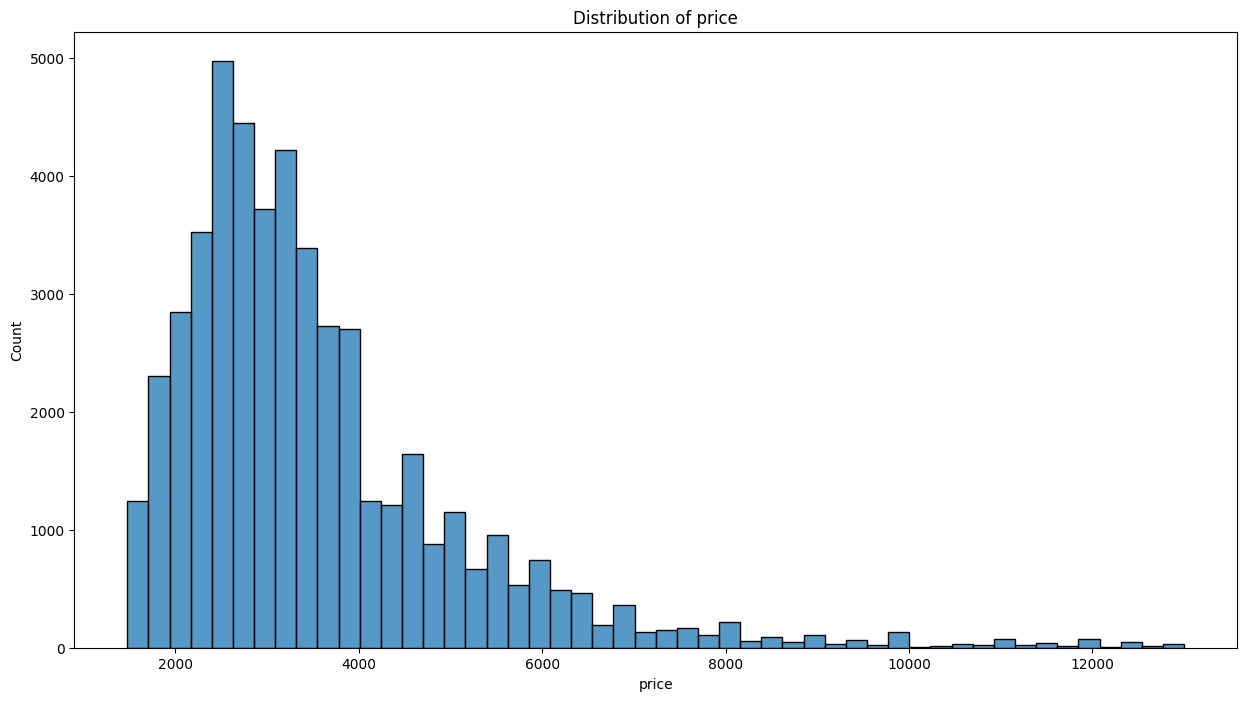

In [13]:
plt.figure(figsize=(15,8))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of price")
plt.show()

After removing the oitliers, the distribution became more even

## Characteristics Analysis

What is the type of column 'interest_level'?

In [14]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  object 
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.8+ MB


,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


Print the values in this column. How many entries does each value contain?

In [15]:
df['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

Encode these values. For example, you can replace each value with 0, 1, or 2.

In [16]:
df['interest_level'] = df['interest_level'].map({'low': 0, 'medium': 1, 'high': 2})

In [17]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  int64  
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 1.8 MB


,bathrooms,bedrooms,interest_level,price
4,1.0,1,1,2400
6,1.0,2,0,3800
9,1.0,2,1,3495
10,1.5,3,1,3000
15,1.0,0,0,2795


Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

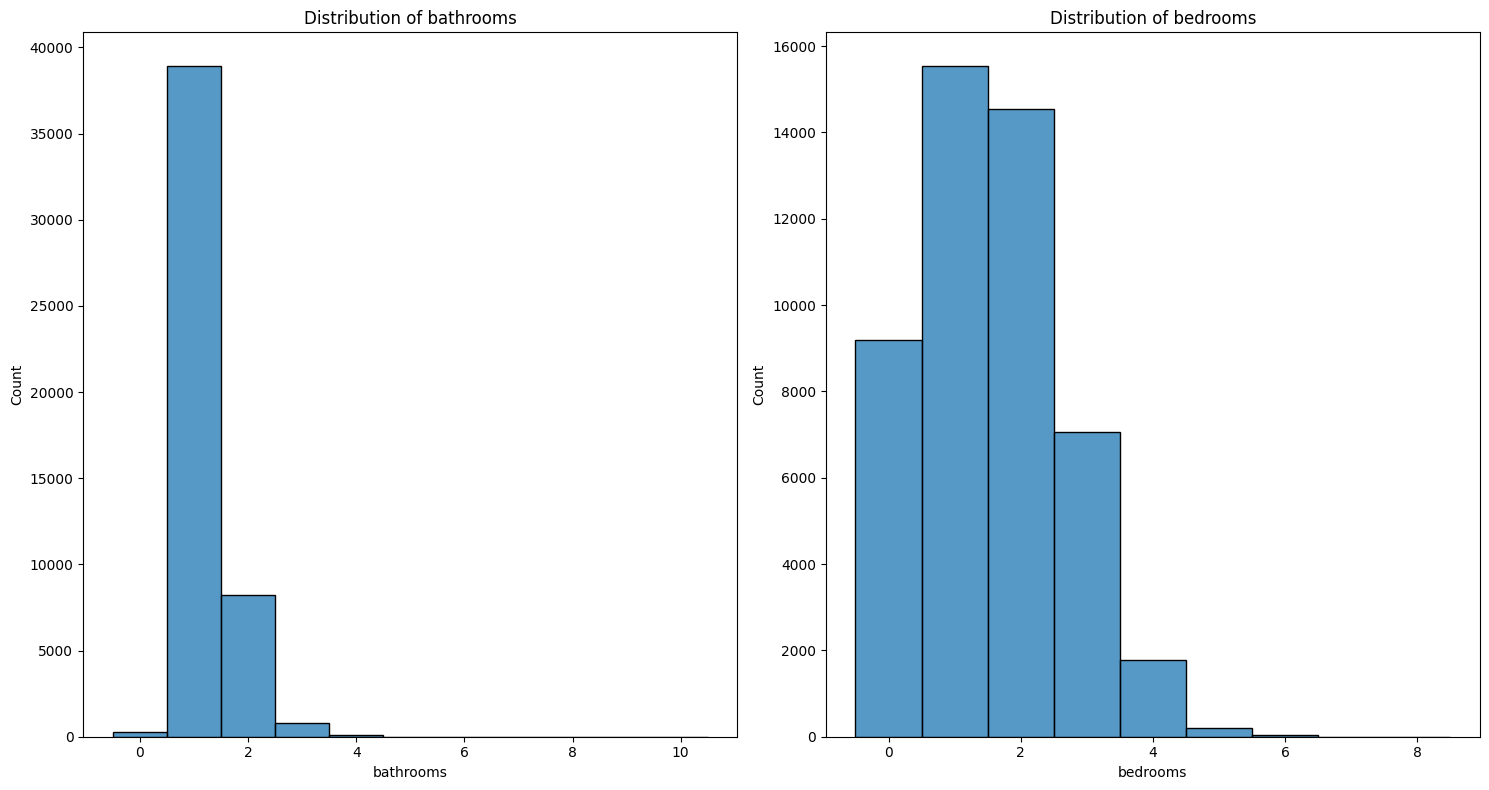

In [18]:
plt.figure(figsize=(15,8))
plt.subplot(1, 2, 1)
sns.histplot(df['bathrooms'], bins=50, discrete=True)
plt.title("Distribution of bathrooms")
plt.subplot(1, 2, 2)
sns.histplot(df['bedrooms'], bins=50, discrete=True)
plt.title("Distribution of bedrooms")
plt.tight_layout()
plt.show()

## Complex analysis

Plot a correlation matrix to understand the correlation between features and target. Plot a heat map for the correlation matrix. Is there a correlation?

In [19]:
cor_matrix = df.corr(numeric_only=True)
cor_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


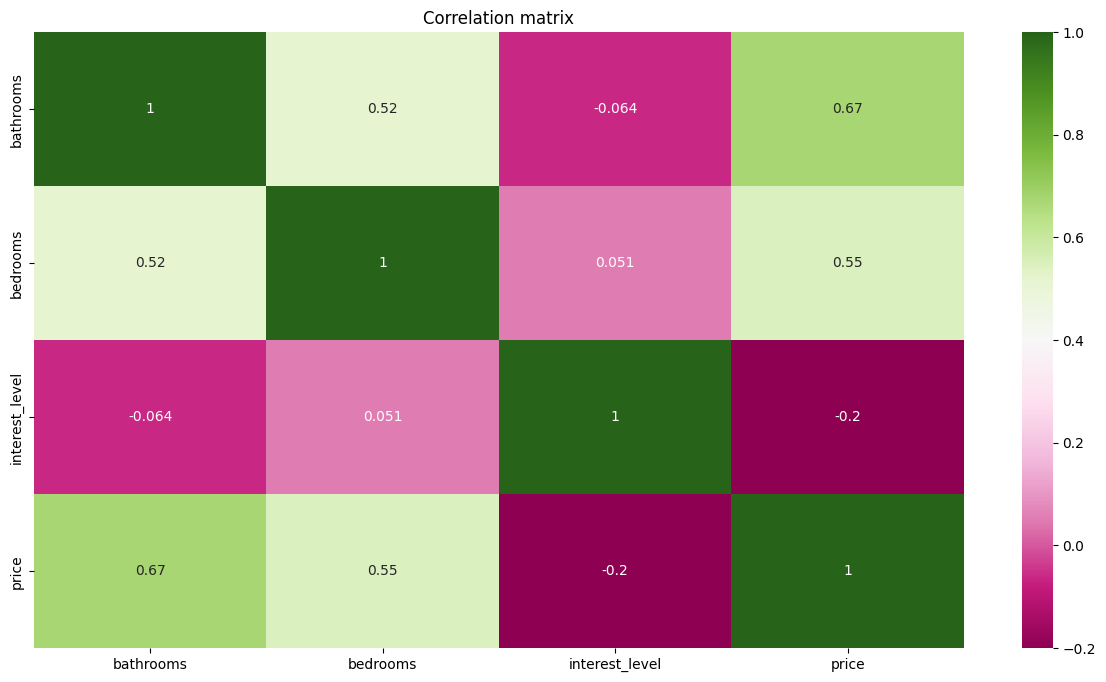

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(cor_matrix, annot=True, cmap='PiYG')
plt.title('Correlation matrix')
plt.show()

Plot a scatterplot to visualize the correlation between the features and the target. You should return 3 plots where the X-axis is the target and the Y-axis is a feature.

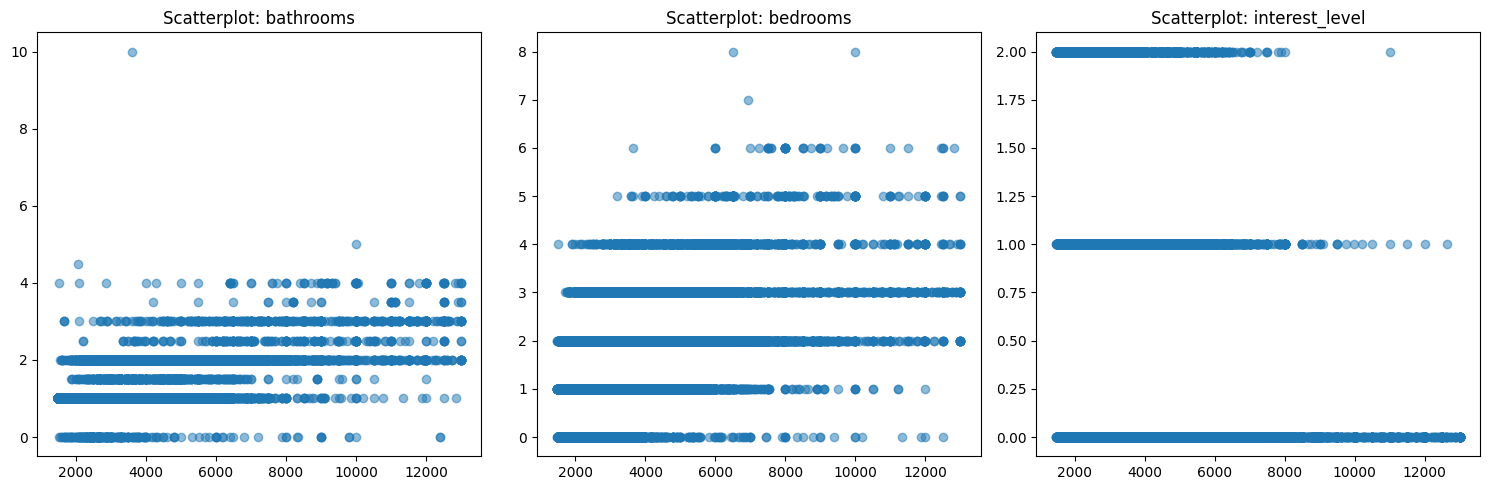

In [21]:
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
plt.scatter (df['price'], df['bathrooms'], alpha=0.5)
plt.title('Scatterplot: bathrooms')
plt.subplot(1, 3, 2)
plt.scatter (df['price'], df['bedrooms'], alpha=0.5)
plt.title('Scatterplot: bedrooms')
plt.subplot(1, 3, 3)
plt.scatter (df['price'], df['interest_level'], alpha=0.5)
plt.title('Scatterplot: interest_level')
plt.tight_layout()
plt.show()

# 3 - Creating Features

Add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

In [22]:
df_extended = df.copy()
df_extended['bathrooms_squared'] = df_extended['bathrooms'] ** 2
df_extended['bedrooms_squared'] = df_extended['bedrooms'] ** 2
df_extended['interest_level_squared'] = df_extended['interest_level'] ** 2

In [23]:
cor_matrix_extended = df_extended.corr(numeric_only=True)

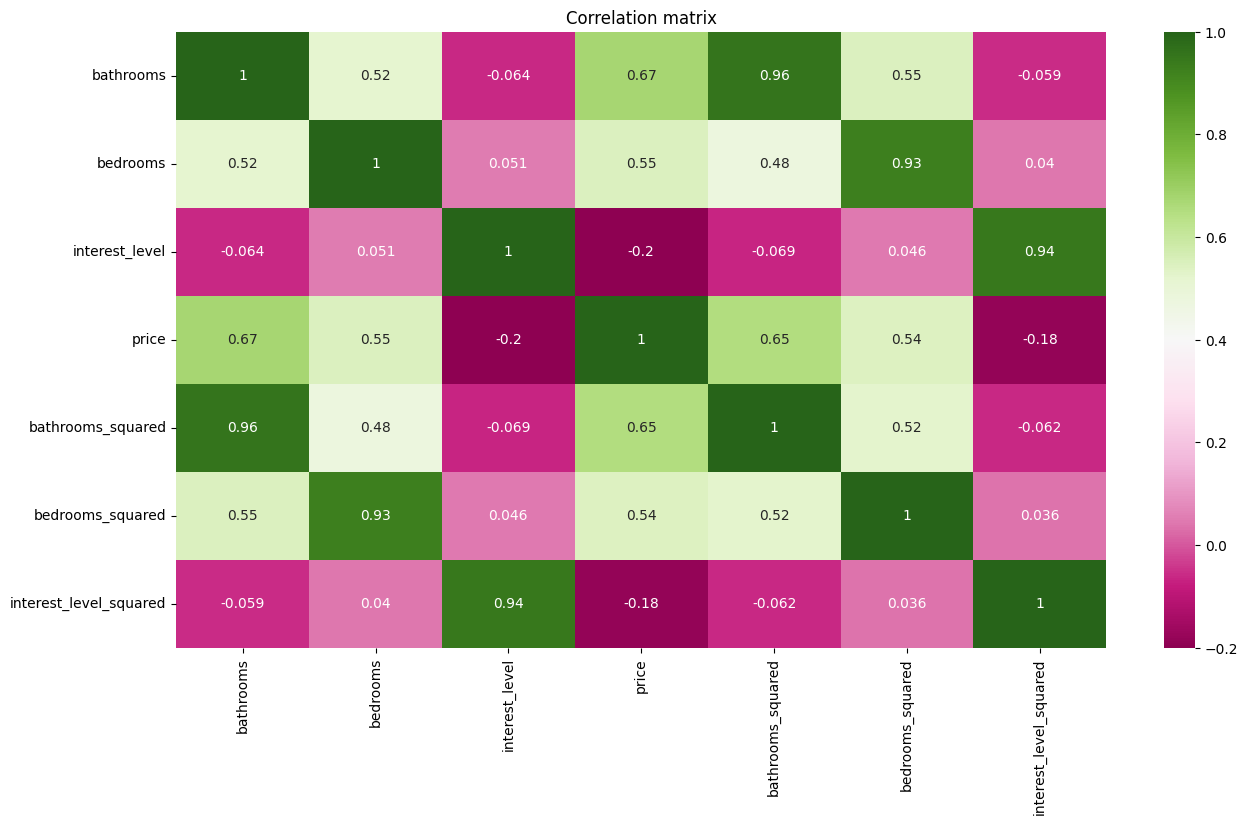

In [24]:
plt.figure(figsize=(15,8))
sns.heatmap(cor_matrix_extended, annot=True, cmap='PiYG')
plt.title('Correlation matrix')
plt.show()

 The new features are not more correlated with the target than the basic features

To train the model here, we will not use your new features, we will only consider the features 'bathrooms' and 'bedrooms'.

To use PolynomialFeatures, we first need to split the data into training and test samples.

In [25]:
train = pd.read_json('data/train.json')
train.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [26]:
test = pd.read_json('data/test.json')
test.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place


In [27]:
low  = train['price'].quantile(0.01)
high = train['price'].quantile(0.99)

train = train[(train['price'] >= low) & (train['price'] <= high)]
test = test[(test['price'] >= low) & (test['price'] <= high)]

In [28]:
X_train = train[['bathrooms', 'bedrooms']]
y_train = train['price']

X_test = test[['bathrooms', 'bedrooms']]
y_test = test['price']

In [29]:
print(f'x_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'x_test: {X_test.shape}, y_test: {y_test.shape}')

x_train: (48379, 2), y_train: (48379,)
x_test: (73255, 2), y_test: (73255,)


# 4 - Training Models

## Results table

Create two empty Pandas DataFrames with columns 'model', 'train', 'test'. Let's call the first one result_MAE and the second one result_RMSE. We will fill these tables with the results of the models.

In [30]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

## Linear Regression

Initialize linear regression from sklearn with no parameters.

In [31]:
model_lr = LinearRegression()

Fit your model and make predictions on training and test features. Save it as new columns in data.

In [32]:
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test  = model_lr.predict(X_test)

Compute MAE (Mean Absolute Error) on training and test targets.

In [33]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

Calculate RMSE (Root Mean Square Error) on training and test objectives.

In [34]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

Insert your metrics into tables result_MAE and result_RMSE with model name 'linear_regression'.

In [35]:
idx = len(result_MAE)
result_MAE.loc[idx] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[idx] = ['linear_regression', rmse_train, rmse_test]

## Decision Tree

Initialize decision tree regressor from sklearn with fixed random_state=21.

In [36]:
model_dt = DecisionTreeRegressor(random_state=21)

Fit it to train features and train target and make prediction on train and test features. Save it as a new column in data.

In [37]:
model_dt.fit(X_train, y_train)

y_pred_train = model_dt.predict(X_train)
y_pred_test  = model_dt.predict(X_test)

Compute MAE (Mean Absolute Error) on train and test targets.

In [38]:
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

Compute RMSE (Root Mean Square Error) on train and test targets.

In [39]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

Insert your metrics into tables result_MAE and result_RMSE with model name 'decision_tree'.

In [40]:
idx = len(result_MAE)
result_MAE.loc[idx] = ['decision_tree', mae_train, mae_test]
result_RMSE.loc[idx] = ['decision_tree', rmse_train, rmse_test]

## Naive Models

Calculate the mean and median of 'price' on the training and test data and create a column with these values.

In [41]:
mean = y_train.mean()
median = y_train.median()

y_pred_mean_train = np.full(len(y_train), mean)
y_pred_mean_test = np.full(len(y_test), mean)

y_pred_median_train = np.full(len(y_train), median)
y_pred_median_test = np.full(len(y_test), median)

Calculate the MAE on the training and test targets between your target and the calculated mean and median.

Calculate the RMSE on the training and test targets between your target and the calculated mean and median.

Insert your metrics into tables result_MAE and result_RMSE with model names 'naive_mean' and 'naive_median'.

In [42]:
mae_train = mean_absolute_error(y_train, y_pred_mean_train)
mae_test  = mean_absolute_error(y_test, y_pred_mean_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_mean_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_mean_test))

idx = len(result_MAE)
result_MAE.loc[idx] = ['naive_mean', mae_train, mae_test]
result_RMSE.loc[idx] = ['naive_mean', rmse_train, rmse_test]

In [43]:
mae_train = mean_absolute_error(y_train, y_pred_median_train)
mae_test = mean_absolute_error(y_test, y_pred_median_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_median_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_median_test))

idx = len(result_MAE)
result_MAE.loc[idx] = ['naive_median', mae_train, mae_test]
result_RMSE.loc[idx] = ['naive_median', rmse_train, rmse_test]

## Compare the results

Print your final result_MAE and result_RMSE tables.

In [44]:
result_MAE

,model,train,test
0,linear_regression,784.563837,790.798082
1,decision_tree,756.044735,759.614776
2,naive_mean,1139.192515,1137.831965
3,naive_median,1086.210505,1084.587987


In [45]:
result_RMSE

,model,train,test
0,linear_regression,1123.877748,1368.601428
1,decision_tree,1077.483596,1081.242292
2,naive_mean,1597.646655,1590.391201
3,naive_median,1644.236439,1635.396216


Which is the best model?

decision tree is the best model